# Análisis de clases y características

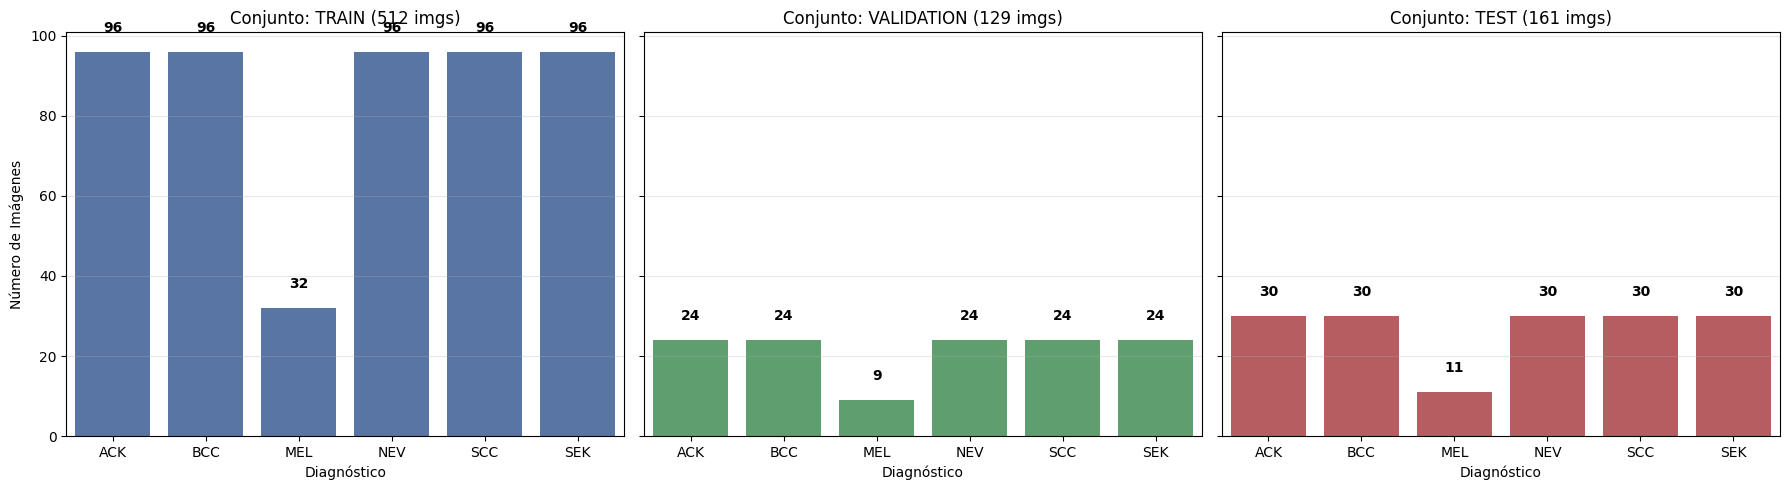

100%|██████████| 802/802 [00:00<00:00, 16031.07it/s]


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


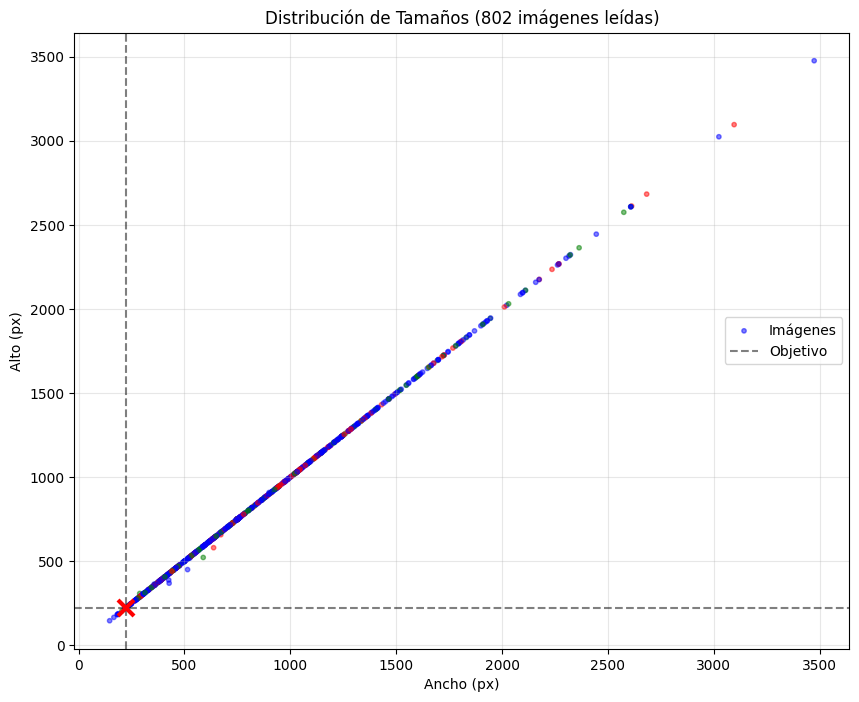

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm # Barra de progreso


CSV_PATH = "../../Datos/Diccionario.csv"

RUTA_RAIZ = "../../Datos/images/MULTICLASE/" 

# Cargar datos
df = pd.read_csv(CSV_PATH)

# ================= PARTE 1: BALANCE DE CLASES =================

# Crear una figura con 3 sub-gráficas (Train, Val, Test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
splits = ['train', 'validation', 'test']
colores = ['#4c72b0', '#55a868', '#c44e52'] # Azul, Verde, Rojo

for i, split in enumerate(splits):
    # Filtrar datos de este split
    datos_split = df[df['conjunto_train_test_val'] == split]
    
    # Contar ocurrencias
    conteo = datos_split['diagnostic'].value_counts().sort_index()
    
    # Dibujar barras
    sns.barplot(x=conteo.index, y=conteo.values, ax=axes[i], color=colores[i])
    
    # Decoración
    axes[i].set_title(f'Conjunto: {split.upper()} ({len(datos_split)} imgs)')
    axes[i].set_xlabel('Diagnóstico')
    axes[i].grid(axis='y', alpha=0.3)
    
    # Poner el número encima de la barra
    for index, value in enumerate(conteo.values):
        axes[i].text(index, value + 5, str(value), ha='center', fontweight='bold')

axes[0].set_ylabel('Número de Imágenes')
plt.tight_layout()
plt.show()

# ================= PARTE 2: TAMAÑO DE IMÁGENES =================

anchos = []
altos = []
colores_puntos = []

# Mapeo de split a color para la gráfica
mapa_colores = {'train': 'blue', 'validation': 'green', 'test': 'red'}

# Recorremos el CSV (usamos tqdm para ver barra de progreso)
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    split = row['conjunto_train_test_val']
    clase = row['diagnostic']
    nombre = row['img_id']
    
    ruta_completa = os.path.join(RUTA_RAIZ, clase, nombre)
    
    # Solo leemos la cabecera del archivo para no cargar toda la imagen (es rápido)
    with Image.open(ruta_completa) as img:
        w, h = img.size
        anchos.append(w)
        altos.append(h)
        colores_puntos.append(mapa_colores.get(split, 'gray'))
    

# Graficar Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)

# Dibujar referencias
plt.axvline(224, color='k', linestyle='--', alpha=0.5)
plt.axhline(224, color='k', linestyle='--', alpha=0.5)
plt.plot(224, 224, 'rx', markersize=12, markeredgewidth=3, label='Objetivo 224x224')

plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes leídas)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(['Imágenes', 'Objetivo'])
plt.grid(True, alpha=0.3)

# Mostrar estadísticas
print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()

Conclusiones que saco de aqui:
Dataset:
1. En el dataset está claro que MEL es el tipo de enfermedad con menos imágenes, por lo que es el que más dificultad va a tener el modelo.
2. Train 500 imágenes, validation 130 y test 160 (Split 70/15/15)
3. La cantidad de datos es baja por lo que tendremos que realizar un data augmentation

Tamaños:
1. Significa que todas las fotops tienen la misma proporción o aspect ratio
2. Podemos usar resize directamente sin usar center_crop


Acciones:
1. Vamos a usar WeightedRandomSampler para forzar al Dataloader a coger la misma cantidad de fotos de cada tipo de enfermedad
2. Usamops batch 32 por temas de memoria y 224 porque es el estándar de oro para finetuning posterior 
3. Hacemos dataugmentation exagerad, y normalizamosd como el datset imagenet qyue es con lo que se entrenaron los modelos que finetunearemos

### Carga de datos,creacdión de dataloaders, balñanceo y data augmentation

In [8]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
# Importamos AMBAS funciones: una para caos (train) y otra para determinismo (val/test)
from ultralytics.data.augment import classify_augmentations, classify_transforms 

# --- 1. CONFIGURACIÓN ---
RUTA_BASE = "../../Datos/images/DATASET_SPLIT" 
BATCH_SIZE = 64 
IMG_SIZE = 224
# Constantes ImageNet (Estándar industrial para Transfer Learning)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# --- 2. DEFINICIÓN DE PIPELINES (Transformaciones) ---

# A. ENTRENAMIENTO: Caos controlado (Exacto a YOLO train)
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0),    # RandomResizedCrop (scale 0.5-1.0)
    hflip=0.5,           # Espejo horizontal
    vflip=0.0,           # Vertical apagado (activar si tus objetos no tienen orientación fija)
    hsv_h=0.015,         # Jitter de color
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.0,         # Ojo: 0.4 es agresivo. Úsalo solo si tienes overfitting. Por defecto 0.0.
)

# B. VAL/TEST: Determinista (Exacto a YOLO predict)
# Esto aplica internamente: Resize(256) -> CenterCrop(224) -> ToTensor -> Normalize
val_test_pipeline = classify_transforms(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    interpolation="BILINEAR" 
)

# --- 3. CARGAR DATASETS ---
# Nota: Corregido el nombre de la variable 'transform'
train_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)
val_dataset   = datasets.ImageFolder(f"{RUTA_BASE}/val",   transform=val_test_pipeline)
test_dataset  = datasets.ImageFolder(f"{RUTA_BASE}/test",  transform=val_test_pipeline)

# --- 4. DATALOADERS ---
# Recomendación: num_workers=4 u 8 si tienes CPU decente. 2 puede ser cuello de botella.
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,          # ¡Importante! Shuffle solo en train
    num_workers=8,         # Ajustar según CPU
    pin_memory=True,       # Acelera transferencia a GPU
    persistent_workers=True # Mantiene workers vivos entre epochs (menos overhead)
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,         # Nunca shuffle en val
    num_workers=4, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

# --- CHECK RAPIDO (Definition of Done) ---
# Ejecuta esto una vez para verificar que las dimensiones son correctas
batch_images, batch_labels = next(iter(train_loader))
print(f"Batch Shape Train: {batch_images.shape}") # Debe ser [64, 3, 224, 224]

batch_images, batch_labels = next(iter(val_loader))
print(f"Batch Shape Val:   {batch_images.shape}") # Debe ser [64, 3, 224, 224]

Batch Shape Train: torch.Size([64, 3, 224, 224])
Batch Shape Val:   torch.Size([64, 3, 224, 224])


### Desnormalizamos y mostramos transformaciones del data augmentation

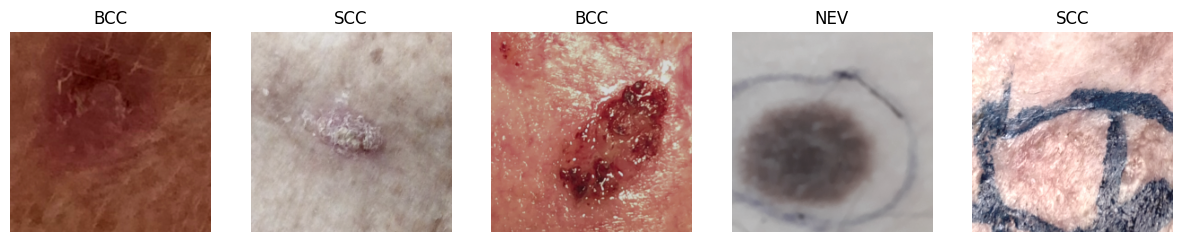

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Sacamos un lote del train_loader (que ya tiene augmentation aplicado)
imgs, labels = next(iter(train_loader))

# Función para des-normalizar y ver la foto bien
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

# Mostramos 5 ejemplos
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_training_history(historial):
    """
    Visualiza la evolución del entrenamiento.
    - Izquierda: Loss (Debe bajar).
    - Derecha: F1-Score Macro (La métrica reina, debe subir).
    """
    epochs = range(1, len(historial['train_loss']) + 1)
    
    plt.figure(figsize=(15, 6))

    # --- GRÁFICA 1: LOSS (Estabilidad) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title('Evolución del Error (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- GRÁFICA 2: F1-MACRO (Calidad Médica) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Validation F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.title('Evolución de la Calidad (F1-Score Macro)')
    plt.xlabel('Épocas')
    plt.ylabel('F1 Score (0.0 - 1.0)')
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label='Mejor F1 alcanzado')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score

def evaluar_rendimiento_completo(model, loader, device, classes, titulo="Set de Datos"):
    """
    Genera:
    1. Matriz de Confusión visual.
    2. Reporte detallado (Precision, Recall, F1 por clase).
    3. Métricas globales (Accuracy, Kappa).
    """
    model.eval()
    y_true = []
    y_pred = []
    
    print(f"\n🔎 Analizando métricas detalladas para: {titulo}...")
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    # --- 1. MATRIZ DE CONFUSIÓN ---
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión - {titulo}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    # --- 2. REPORTES NUMÉRICOS ---
    print(f"\n📋 REPORTE CLÍNICO DETALLADO ({titulo})")
    print("="*70)
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print("-" * 70)
    
    # Métricas Globales
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"✅ Accuracy Global:   {acc:.4f} (Cuidado, dataset desbalanceado)")
    print(f"⚖️  Cohen's Kappa:     {kappa:.4f} (Grado de acuerdo real vs azar)")
    print("="*70)

import copy
import torch.nn as nn
from sklearn.metrics import f1_score
import torch.optim as optim

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    
    print(f"🚀 Iniciando entrenamiento por {epochs} épocas...")
    print(f"💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)")
    
    # --- SCHEDULER: Reduce LR cuando F1 se estanca ---
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='max',      # Maximizar F1
        factor=0.5,      # Reduce LR a la mitad
        patience=3      # Espera 3 épocas sin mejora
        
    )
    
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # --- FASE 1: ENTRENAMIENTO ---
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # --- FASE 2: VALIDACIÓN ---
        model.eval()
        val_loss = 0.0
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        epoch_val_loss = val_loss / len(val_loader.dataset)
        
        # CALCULAMOS F1 MACRO (La métrica que decide si guardamos)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')
        
        # --- ACTUALIZAR SCHEDULER ---
        scheduler.step(epoch_val_f1)
        
        # Guardar en historial
        historial['train_loss'].append(epoch_train_loss)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)
        
        # Mensaje de progreso
        print(f"Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}", end="")
        
        # --- LÓGICA SMART SAVING ---
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            print(" 🏆 ¡Récord! Guardado.")
        else:
            print("") # Salto de línea

    print(f"\n🏁 Fin. Mejor F1 Val: {best_f1:.4f}")
    
    # IMPORTANTE: Devolvemos el modelo con los MEJORES pesos, no los últimos
    model.load_state_dict(best_model_wts)
    return model, historial

def lanzar_experimento(modelo, nombre_exp, train_loader, val_loader, test_loader, device, optimizer_ft):
    """
    Ejecuta todo el pipeline: Entrena -> Muestra Evolución -> Evalúa en Test
    """
    print(f"\n{'='*30}\n▶️ EXPERIMENTO: {nombre_exp}\n{'='*30}")
    
    # --- PASO 1: CALCULAR PESOS DE CLASE (Correctamente) ---
    labels_list = train_loader.dataset.targets
    class_counts = np.bincount(labels_list)
    
    # Fórmula: Peso = 1 / frecuencia
    weights = 1.0 / class_counts
    weights = weights / weights.sum() * len(class_counts)
    
    # Convertir a Tensor float32 y mover a GPU
    class_weights = torch.FloatTensor(weights).to(device)
    
    print(f"⚖️ Pesos de clase calculados: {class_weights.cpu().numpy()}")
    
    # --- PASO 2: CONFIGURAR LOSS CON LABEL SMOOTHING ---
    # Label smoothing ayuda a reducir overfitting y mejora generalización
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    
    # Optimizador
    optimizer = optimizer_ft
    
    # --- PASO 3: ENTRENAMIENTO ---
    modelo_entrenado, historial = entrenar_modelo(
        modelo, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        device, 
        epochs=25, 
        nombre_archivo=f"{nombre_exp}_best.pth"
    )
    
    # --- PASO 4: VISUALIZACIÓN ---
    print(f"\n📈 Visualizando aprendizaje de: {nombre_exp}")
    plot_training_history(historial)
    
    # --- PASO 5: TEST FINAL ---
    print(f"\n🎯 Resultados finales en TEST SET (Datos nunca vistos)")
    evaluar_rendimiento_completo(
        modelo_entrenado, 
        test_loader, 
        device, 
        train_loader.dataset.classes, 
        titulo=f"TEST - {nombre_exp}"
    )
    
    return modelo_entrenado

Usando device: cuda

▶️ EXPERIMENTO: ResNet18_Baseline
⚖️ Pesos de clase calculados: [       0.75        0.75        2.25        0.75        0.75        0.75]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 1.953 | Val Loss: 1.706 | Val F1: 0.4009 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 1.657 | Val Loss: 1.500 | Val F1: 0.3752
Ep 3/25 | Train Loss: 1.422 | Val Loss: 1.477 | Val F1: 0.3924
Ep 4/25 | Train Loss: 1.369 | Val Loss: 1.382 | Val F1: 0.4630 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 1.290 | Val Loss: 1.375 | Val F1: 0.4938 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 1.212 | Val Loss: 1.344 | Val F1: 0.5281 🏆 ¡Récord! Guardado.
Ep 7/25 | Train Loss: 1.140 | Val Loss: 1.344 | Val F1: 0.5349 🏆 ¡Récord! Guardado.
Ep 8/25 | Train Loss: 1.099 | Val Loss: 1.332 | Val F1: 0.5398 🏆 ¡Récord! Guardado.
Ep 9/25 | Train Loss: 1.066 | Val Loss: 1.376 | Val F1: 0.5265
Ep 10/25 | Train Loss: 1.032 | Val Loss: 1.

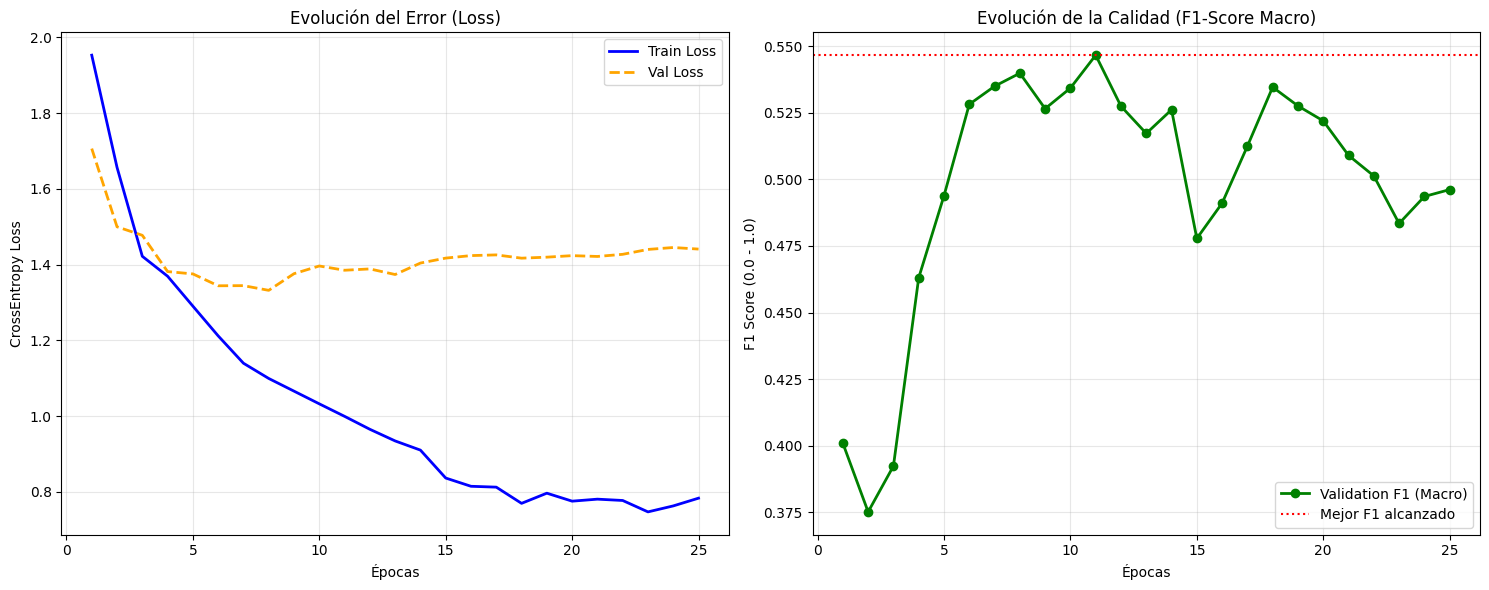


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - ResNet18_Baseline...


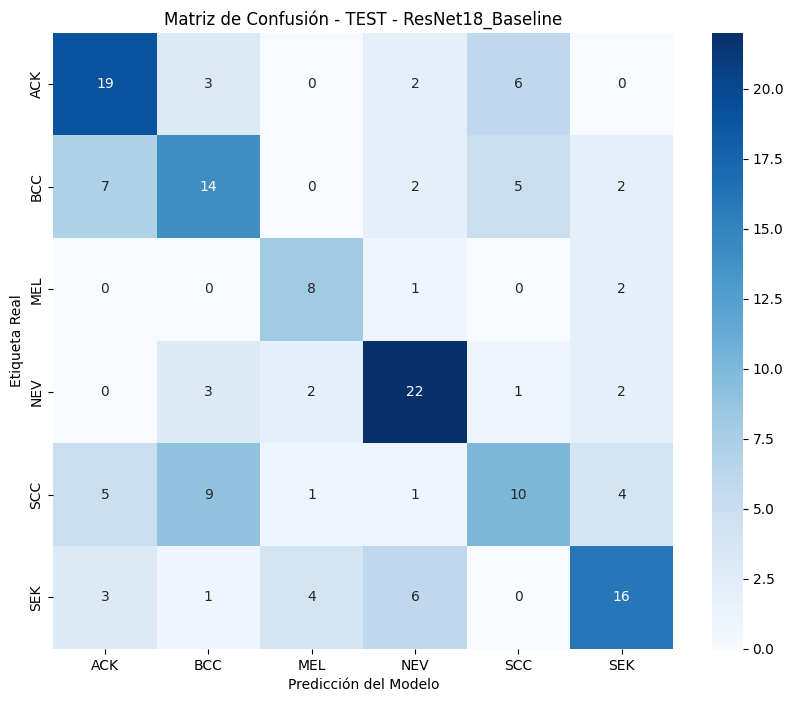


📋 REPORTE CLÍNICO DETALLADO (TEST - ResNet18_Baseline)
              precision    recall  f1-score   support

         ACK       0.56      0.63      0.59        30
         BCC       0.47      0.47      0.47        30
         MEL       0.53      0.73      0.62        11
         NEV       0.65      0.73      0.69        30
         SCC       0.45      0.33      0.38        30
         SEK       0.62      0.53      0.57        30

    accuracy                           0.55       161
   macro avg       0.55      0.57      0.55       161
weighted avg       0.55      0.55      0.55       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5528 (Cuidado, dataset desbalanceado)
⚖️  Cohen's Kappa:     0.4577 (Grado de acuerdo real vs azar)


In [11]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# ==========================================
# 1. CARGAR RESNET-18
# ==========================================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# ==========================================
# 2. ESTRATEGIA: CONGELAR PRIMERO, DESCONGELAR LO IMPORTANTE
# ==========================================
# Paso A: Congelar todo (Base sólida)
for param in model.parameters():
    param.requires_grad = False

# Paso B: DESCONGELAR el último bloque convolucional (Layer 4)
for param in model.layer4.parameters():
    param.requires_grad = True

# ==========================================
# 3. ADAPTAR LA CABEZA
# ==========================================
num_ftrs = model.fc.in_features
num_classes = len(train_loader.dataset.classes)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# ==========================================
# 4. OPTIMIZADOR CON MÁS REGULARIZACIÓN
# ==========================================
# weight_decay subido de 0.01 a 0.05 para reducir overfitting
optimizer_ft = optim.AdamW([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
], weight_decay=0.05)

# ==========================================
# 5. LANZAR EXPERIMENTO
# ==========================================
model_resnet = lanzar_experimento(
    modelo=model,
    nombre_exp="ResNet18_Baseline",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft
)

Usando device: cuda
🔄 Cargando DenseNet-121 (El especialista médico)...

▶️ EXPERIMENTO: DenseNet121_MedicalExpert
⚖️ Pesos de clase calculados: [       0.75        0.75        2.25        0.75        0.75        0.75]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 1.896 | Val Loss: 1.690 | Val F1: 0.3331 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 1.669 | Val Loss: 1.543 | Val F1: 0.4364 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 1.517 | Val Loss: 1.473 | Val F1: 0.4676 🏆 ¡Récord! Guardado.
Ep 4/25 | Train Loss: 1.482 | Val Loss: 1.434 | Val F1: 0.4898 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 1.347 | Val Loss: 1.395 | Val F1: 0.4615
Ep 6/25 | Train Loss: 1.335 | Val Loss: 1.370 | Val F1: 0.4812
Ep 7/25 | Train Loss: 1.305 | Val Loss: 1.362 | Val F1: 0.5193 🏆 ¡Récord! Guardado.
Ep 8/25 | Train Loss: 1.263 | Val Loss: 1.341 | Val F1: 0.5198 🏆 ¡Récord! Guardado.
Ep 9/25 | Train Loss: 1.236 | Val Loss: 1.329 

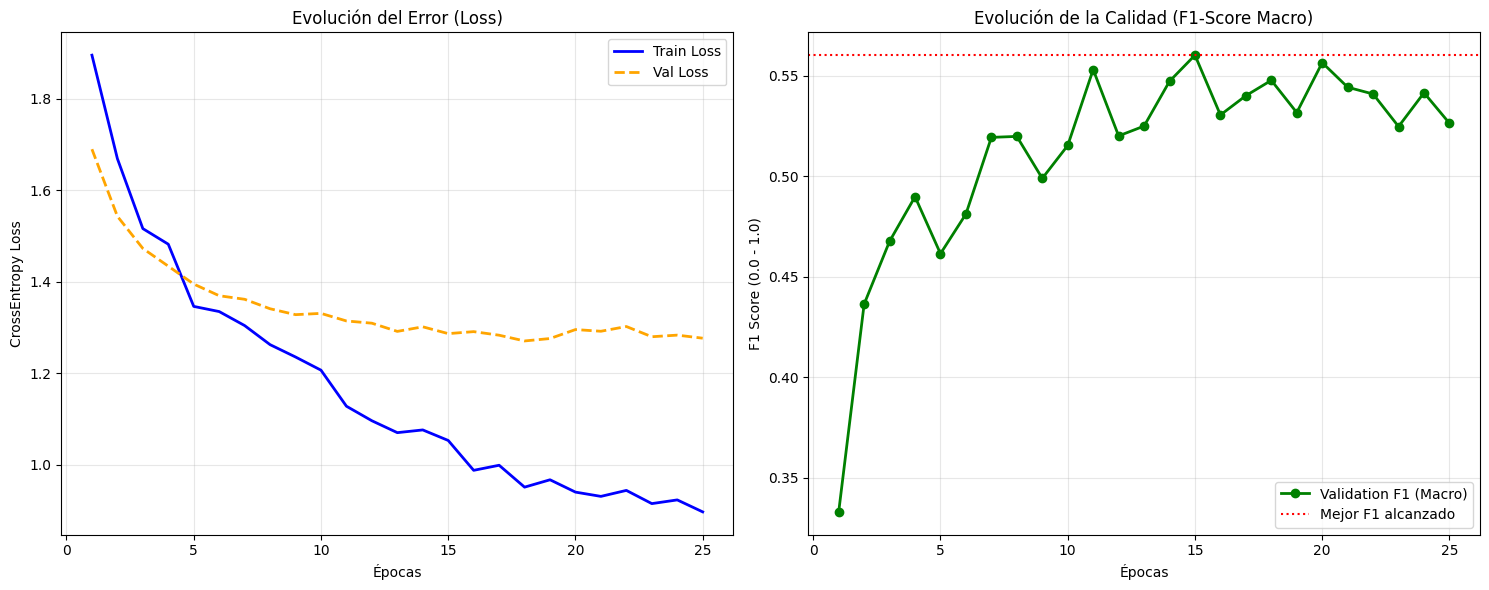


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - DenseNet121_MedicalExpert...


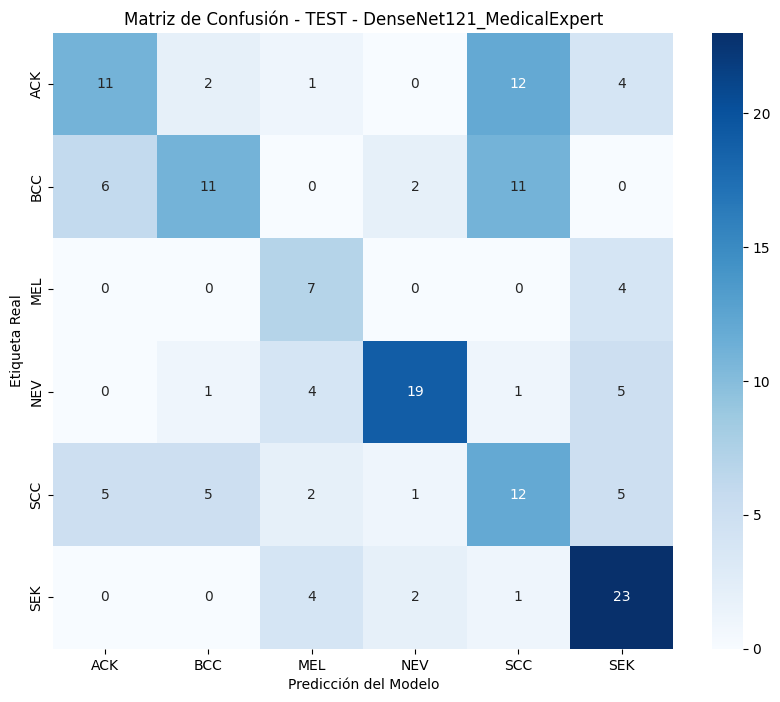


📋 REPORTE CLÍNICO DETALLADO (TEST - DenseNet121_MedicalExpert)
              precision    recall  f1-score   support

         ACK       0.50      0.37      0.42        30
         BCC       0.58      0.37      0.45        30
         MEL       0.39      0.64      0.48        11
         NEV       0.79      0.63      0.70        30
         SCC       0.32      0.40      0.36        30
         SEK       0.56      0.77      0.65        30

    accuracy                           0.52       161
   macro avg       0.52      0.53      0.51       161
weighted avg       0.54      0.52      0.51       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5155 (Cuidado, dataset desbalanceado)
⚖️  Cohen's Kappa:     0.4141 (Grado de acuerdo real vs azar)


In [16]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# ==========================================
# 1. CARGAR DENSENET-121
# ==========================================
print("🔄 Cargando DenseNet-121 (El especialista médico)...")
weights = models.DenseNet121_Weights.DEFAULT
model = models.densenet121(weights=weights)

# ==========================================
# 2. ESTRATEGIA DE CONGELADO (Smart Freezing)
# ==========================================
for param in model.features.parameters():
    param.requires_grad = False

# Descongelar denseblock4 y norm5
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
    
for param in model.features.norm5.parameters():
    param.requires_grad = True

# ==========================================
# 3. ADAPTAR LA CABEZA (Classifier)
# ==========================================
num_ftrs = model.classifier.in_features
num_classes = len(train_loader.dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# ==========================================
# 4. OPTIMIZADOR CON MÁS REGULARIZACIÓN
# ==========================================
# weight_decay subido de 0.01 a 0.05 para reducir overfitting
optimizer_ft = optim.AdamW([
    {'params': model.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model.features.norm5.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=0.05)

# ==========================================
# 5. LANZAR EXPERIMENTO
# ==========================================
model_densenet = lanzar_experimento(
    modelo=model,
    nombre_exp="DenseNet121_MedicalExpert",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft
)

Usando device: cuda
🔄 Cargando ConvNeXt-Tiny (La ConvNet modernizada)...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /home/dmore/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:03<00:00, 35.2MB/s] 



▶️ EXPERIMENTO: ConvNeXt_Tiny
⚖️ Pesos de clase calculados: [       0.75        0.75        2.25        0.75        0.75        0.75]
🚀 Iniciando entrenamiento por 25 épocas...
💾 Criterio de Guardado: Maximizar Validation F1-Score (Macro)
Ep 1/25 | Train Loss: 1.797 | Val Loss: 1.664 | Val F1: 0.3907 🏆 ¡Récord! Guardado.
Ep 2/25 | Train Loss: 1.576 | Val Loss: 1.504 | Val F1: 0.4100 🏆 ¡Récord! Guardado.
Ep 3/25 | Train Loss: 1.364 | Val Loss: 1.416 | Val F1: 0.4772 🏆 ¡Récord! Guardado.
Ep 4/25 | Train Loss: 1.201 | Val Loss: 1.319 | Val F1: 0.5380 🏆 ¡Récord! Guardado.
Ep 5/25 | Train Loss: 1.131 | Val Loss: 1.305 | Val F1: 0.5459 🏆 ¡Récord! Guardado.
Ep 6/25 | Train Loss: 1.044 | Val Loss: 1.279 | Val F1: 0.6088 🏆 ¡Récord! Guardado.
Ep 7/25 | Train Loss: 0.943 | Val Loss: 1.319 | Val F1: 0.5788
Ep 8/25 | Train Loss: 0.925 | Val Loss: 1.276 | Val F1: 0.5431
Ep 9/25 | Train Loss: 0.824 | Val Loss: 1.327 | Val F1: 0.5507
Ep 10/25 | Train Loss: 0.807 | Val Loss: 1.310 | Val F1: 0.5542
Ep 

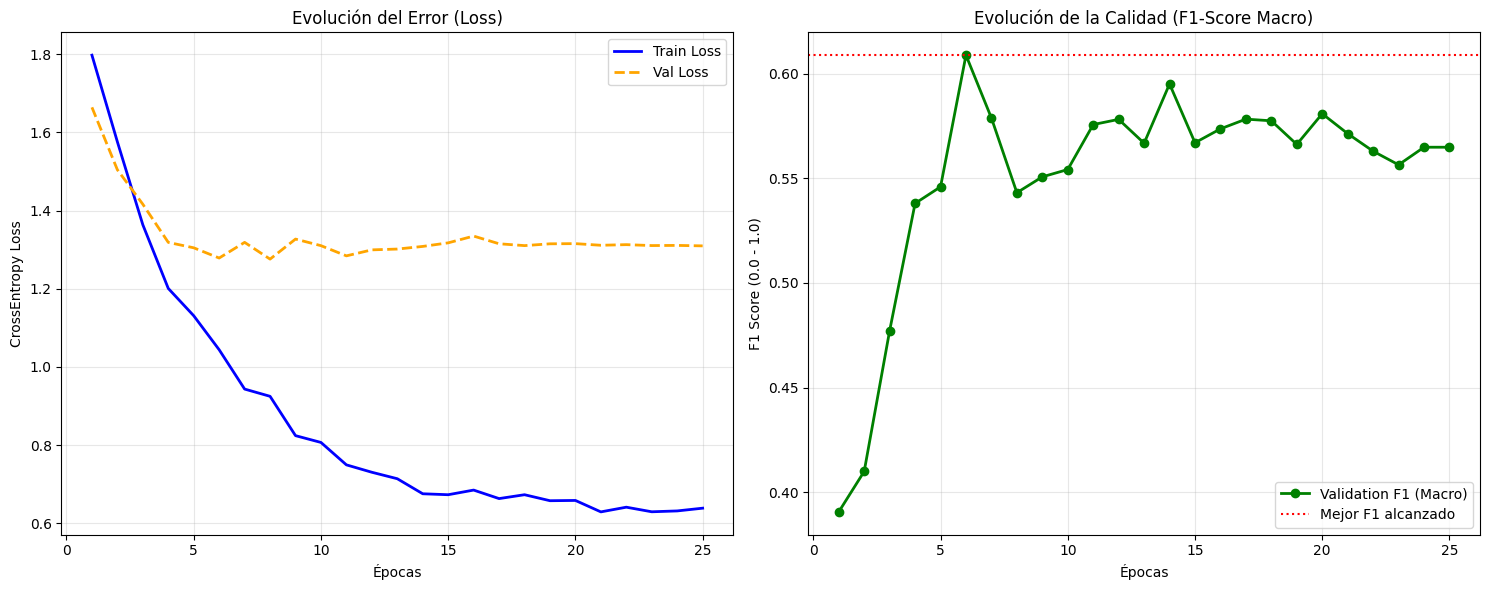


🎯 Resultados finales en TEST SET (Datos nunca vistos)

🔎 Analizando métricas detalladas para: TEST - ConvNeXt_Tiny...


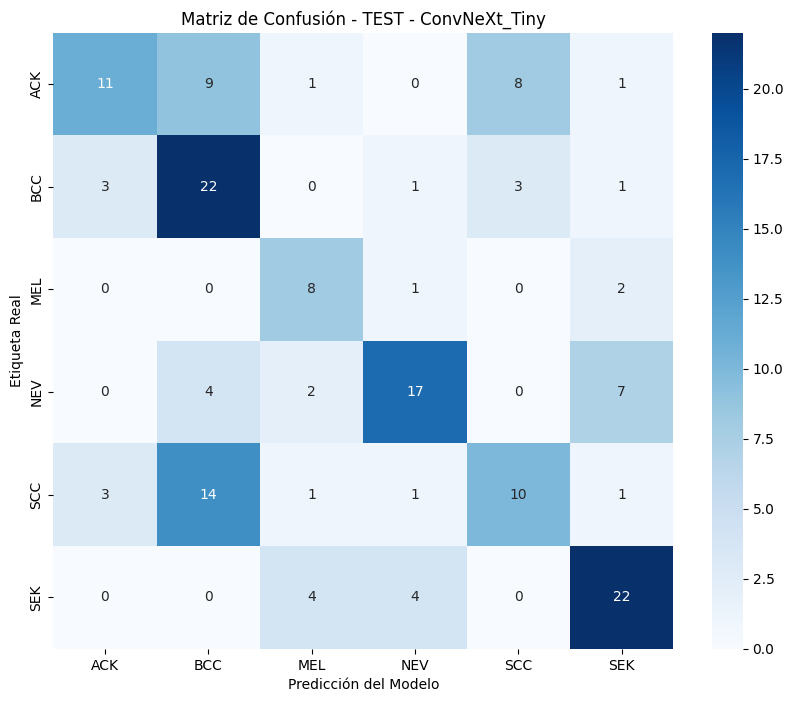


📋 REPORTE CLÍNICO DETALLADO (TEST - ConvNeXt_Tiny)
              precision    recall  f1-score   support

         ACK       0.65      0.37      0.47        30
         BCC       0.45      0.73      0.56        30
         MEL       0.50      0.73      0.59        11
         NEV       0.71      0.57      0.63        30
         SCC       0.48      0.33      0.39        30
         SEK       0.65      0.73      0.69        30

    accuracy                           0.56       161
   macro avg       0.57      0.58      0.55       161
weighted avg       0.58      0.56      0.55       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5590 (Cuidado, dataset desbalanceado)
⚖️  Cohen's Kappa:     0.4657 (Grado de acuerdo real vs azar)


In [17]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# ==========================================
# 1. CARGAR CONVNEXT-TINY (Arquitectura moderna 2022)
# ==========================================
print("🔄 Cargando ConvNeXt-Tiny (La ConvNet modernizada)...")
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
model = models.convnext_tiny(weights=weights)

# ==========================================
# 2. ESTRATEGIA DE CONGELADO
# ==========================================
# ConvNeXt tiene estructura: features (7 stages) + classifier
# Congelamos todo primero
for param in model.parameters():
    param.requires_grad = False

# Descongelamos los últimos 2 stages (stages 5 y 6) del feature extractor
# model.features tiene índices [0-6], los últimos son los más abstractos
for param in model.features[5].parameters():
    param.requires_grad = True
for param in model.features[6].parameters():
    param.requires_grad = True

# ==========================================
# 3. ADAPTAR LA CABEZA (Classifier)
# ==========================================
# ConvNeXt classifier: LayerNorm2d -> Flatten -> Linear
# Accedemos al Linear que está en classifier[2]
num_ftrs = model.classifier[2].in_features
num_classes = len(train_loader.dataset.classes)

model.classifier[2] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, num_classes)
)

model = model.to(device)

# ==========================================
# 4. OPTIMIZADOR CON REGULARIZACIÓN
# ==========================================
optimizer_ft = optim.AdamW([
    {'params': model.features[5].parameters(), 'lr': 1e-4},
    {'params': model.features[6].parameters(), 'lr': 1e-4},
    {'params': model.classifier[2].parameters(), 'lr': 1e-3}
], weight_decay=0.05)

# ==========================================
# 5. LANZAR EXPERIMENTO
# ==========================================
model_convnext = lanzar_experimento(
    modelo=model,
    nombre_exp="ConvNeXt_Tiny",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    optimizer_ft=optimizer_ft
)

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
from ultralytics import YOLO

def evaluar_yolo_clinico(ruta_modelo, carpeta_test):
    """
    Replica la evaluación clínica detallada para modelos YOLO.
    Genera:
    1. Matriz de Confusión (Seaborn heatmap).
    2. Reporte de Clasificación (Precision, Recall, F1).
    3. Métricas Globales (Accuracy, Kappa).
    """
    
    print(f"🔄 Cargando modelo YOLO desde: {ruta_modelo}")
    model = YOLO(ruta_modelo)
    
    print(f"🔎 Analizando métricas en TEST SET: {carpeta_test} ...")
    
    y_true = []
    y_pred = []
    
    # Mapeo inverso: Nombre Clase -> Índice (Ej: 'MEL' -> 0)
    # YOLO guarda los nombres en model.names {0: 'ACK', 1: 'BCC'...}
    name_to_idx = {v: k for k, v in model.names.items()}
    
    # Recorremos la carpeta de TEST imagen por imagen
    # Estructura esperada: carpeta_test/CLASE/imagen.jpg
    
    # Obtenemos las clases ordenadas por índice para que la matriz salga bien
    sorted_indices = sorted(model.names.keys())
    class_names = [model.names[i] for i in sorted_indices]
    
    # Iteramos sobre las carpetas de clase
    for cls_name in os.listdir(carpeta_test):
        cls_path = os.path.join(carpeta_test, cls_name)
        
        # Ignoramos archivos sueltos, solo queremos carpetas
        if not os.path.isdir(cls_path):
            continue
            
        if cls_name not in name_to_idx:
            print(f"⚠️ Advertencia: La carpeta '{cls_name}' no es una clase conocida por el modelo.")
            continue
            
        true_idx = name_to_idx[cls_name]
        
        # Iteramos sobre las imágenes dentro de la clase
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for file in files:
            img_path = os.path.join(cls_path, file)
            
            # --- PREDICCIÓN YOLO ---
            # verbose=False para que no llene la pantalla de logs
            results = model(img_path, verbose=False)
            
            # Extraemos la clase con mayor probabilidad (Top-1)
            pred_idx = results[0].probs.top1
            
            y_true.append(true_idx)
            y_pred.append(pred_idx)
            
    # --- 1. MATRIZ DE CONFUSIÓN VISUAL ---
    cm = confusion_matrix(y_true, y_pred, labels=sorted_indices)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - YOLO11x (Test)')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.show()
    
    # --- 2. REPORTES NUMÉRICOS ---
    print(f"\n📋 REPORTE CLÍNICO DETALLADO (YOLO11x)")
    print("="*70)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("-" * 70)
    
    # Métricas Globales
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"✅ Accuracy Global:   {acc:.4f}")
    print(f"⚖️  Cohen's Kappa:    {kappa:.4f}")
    print("="*70)


In [18]:
from ultralytics import YOLO
import os

# 1. Definir la ruta a TUS datos (Asegúrate de haber renombrado 'validation' a 'val')
# Usa ruta absoluta si quieres evitar problemas, o relativa si sabes dónde estás.
dataset_path = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT"

# 2. Cargar el modelo YOLO11x (Classification)
model = YOLO('yolo26x-cls.pt')  # Se descarga solo la primera vez

print(f"🚀 Lanzando entrenamiento con datos en: {dataset_path}")

# 3. Entrenar
results = model.train(
    data=dataset_path,  # <--- Apunta directamente a tu carpeta existente
    epochs=25,
    imgsz=224,
    batch=16,           # Si te da error de memoria (CUDA OOM), baja a 8
    patience=5,         # Early stopping
    project='SkinCancer_Project',
    name='YOLO26x_Run',
    lr0=0.0001,
    optimizer='AdamW',
    weight_decay=0.05,
    cos_lr=True
)

🚀 Lanzando entrenamiento con datos en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7741.9±881.4 MB/s, size: 1837.7 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/train... 512 images, 0 corrupt: 100% ━━━━━━━━━━━━ 512/512 74.1Mit/s 0.0s
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1402.3±1416.0 MB/s, size: 1350.9 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/val... 129 images, 0 corrupt: 100% ━━━━━━━━━━━━ 129/129 7.3Mit/s 0.0s
optimizer: AdamW(lr=0.0001, momentum=0.937) with parameter groups 82 weight(decay=0.0), 83 weight(decay=0.05), 83 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO26x_Run
Starting training for 25 epochs...

      Epoch    GPU_

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/25      3.27G      1.653         16        224: 100% ━━━━━━━━━━━━ 32/32 4.2it/s 7.6s<0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 6.6it/s 0.8s0.4s
                   all      0.434      0.969

      Epoch    GPU_mem       loss  Instances       Size
       2/25      3.27G      1.312         16        224: 0% ──────────── 0/32  0.2s

...

      18/25      3.34G     0.4297         16        224: 100% ━━━━━━━━━━━━ 32/32 7.9it/s 4.0s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.0it/s 0.3s.1s
                   all      0.558          1

      Epoch    GPU_mem       loss  Instances       Size
      19/25      3.39G     0.5207         16        224: 0% ──────────── 0/32  0.1s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      19/25       3.4G     0.4747         16        224: 100% ━━━━━━━━━━━━ 32/32 8.1it/s 4.0s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 16.9it/s 0.3s.1s
                   all      0.558          1

      Epoch    GPU_mem       loss  Instances       Size
      20/25      3.44G     0.5237         16        224: 0% ──────────── 0/32  0.1s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      20/25      3.46G      0.503         16        224: 100% ━━━━━━━━━━━━ 32/32 8.2it/s 3.9s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.9it/s 0.3s.1s
                   all       0.55          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 15, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

20 epochs completed in 0.030 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO26x_Run/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO26x_Run/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL

🔄 Cargando modelo YOLO desde: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO26x_Run/weights/best.pt
🔎 Analizando métricas en TEST SET: ../Datos/images/DATASET_SPLIT/test ...


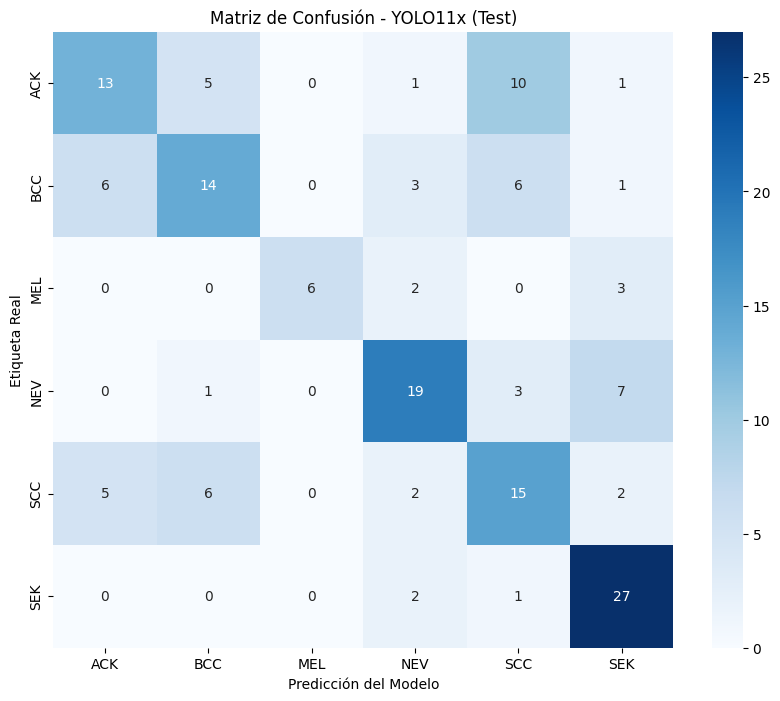


📋 REPORTE CLÍNICO DETALLADO (YOLO11x)
              precision    recall  f1-score   support

         ACK       0.54      0.43      0.48        30
         BCC       0.54      0.47      0.50        30
         MEL       1.00      0.55      0.71        11
         NEV       0.66      0.63      0.64        30
         SCC       0.43      0.50      0.46        30
         SEK       0.66      0.90      0.76        30

    accuracy                           0.58       161
   macro avg       0.64      0.58      0.59       161
weighted avg       0.59      0.58      0.58       161

----------------------------------------------------------------------
✅ Accuracy Global:   0.5839
⚖️  Cohen's Kappa:    0.4913


In [20]:
# --- EJECUCIÓN ---
# Ajusta las rutas si es necesario
ruta_pesos = '/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/runs/classify/SkinCancer_Project/YOLO26x_Run/weights/best.pt'
ruta_test = '../Datos/images/DATASET_SPLIT/test'

evaluar_yolo_clinico(ruta_pesos, ruta_test)

📋 Clases detectadas: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
🔄 Cargando Modelos PyTorch...
✅ PyTorch Models Loaded (ResNet18, DenseNet121, ConvNeXt-Tiny)
🔄 Cargando Modelo YOLO26x...
✅ YOLO26x Loaded.

🚀 Iniciando Inferencia Ensemble en 6 clases...
📊 Modelos: ResNet18 + DenseNet121 + ConvNeXt-Tiny + YOLO26x

🏆 RESULTADOS DEL ENSEMBLE DEFINITIVO
📊 ResNet18 + DenseNet121 + ConvNeXt-Tiny + YOLO26x
              precision    recall  f1-score   support

         ACK       0.59      0.43      0.50        30
         BCC       0.54      0.50      0.52        30
         MEL       0.67      0.55      0.60        11
         NEV       0.72      0.70      0.71        30
         SCC       0.45      0.50      0.48        30
         SEK       0.68      0.90      0.77        30

    accuracy                           0.60       161
   macro avg       0.61      0.60      0.60       161
weighted avg       0.60      0.60      0.60       161



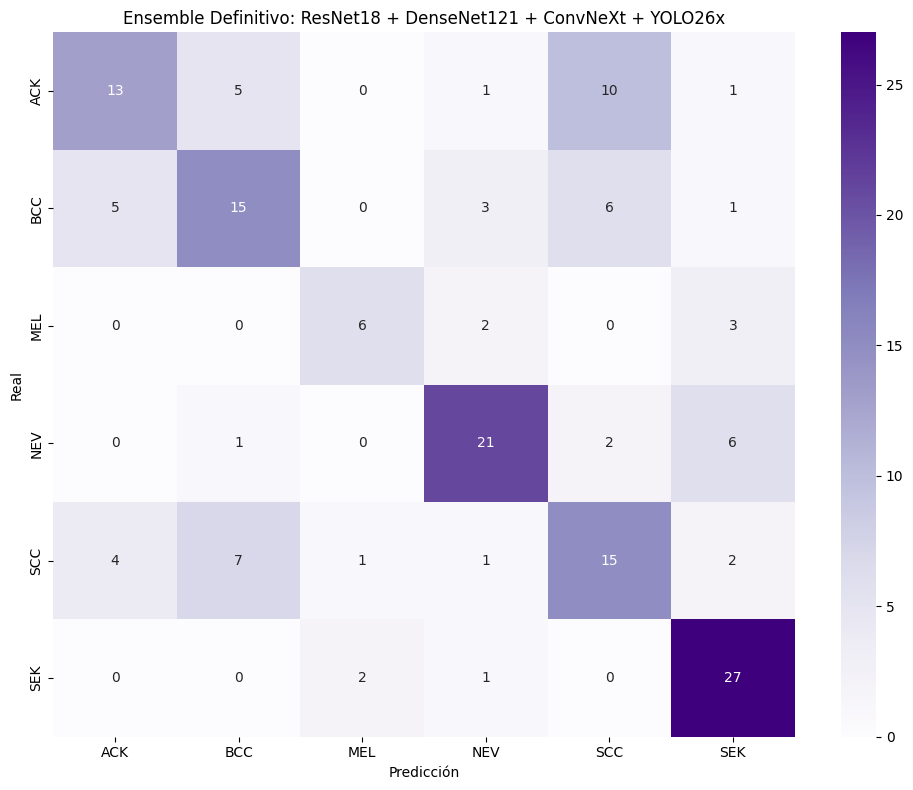


✅ Accuracy Global Ensemble: 0.6025
⚖️  Cohen's Kappa:            0.5154


In [5]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from ultralytics import YOLO
from PIL import Image
import os
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
carpeta_test = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/DATASET_SPLIT/test"

# RUTAS DE LOS PESOS
ruta_resnet = "ResNet18_Baseline_best.pth"
ruta_densenet = "DenseNet121_MedicalExpert_best.pth"
ruta_convnext = "ConvNeXt_Tiny_best.pth"
ruta_yolo = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/Tercera_prueba/runs/classify/SkinCancer_Project/YOLO26x_Run/weights/best.pt"

# Clases en orden alfabético (Es el estándar de ImageFolder)
clases = sorted(os.listdir(carpeta_test))
print(f"📋 Clases detectadas: {clases}")

# ==========================================
# 2. FUNCIONES PARA CARGAR MODELOS PYTORCH
# ==========================================
def cargar_resnet(path, num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features, num_classes))
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

def cargar_densenet(path, num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.classifier.in_features, num_classes))
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

def cargar_convnext(path, num_classes):
    model = models.convnext_tiny(weights=None)
    num_ftrs = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

# ==========================================
# 3. CARGAR TODOS LOS MODELOS
# ==========================================
print("🔄 Cargando Modelos PyTorch...")
try:
    model_res = cargar_resnet(ruta_resnet, len(clases))
    model_dense = cargar_densenet(ruta_densenet, len(clases))
    model_conv = cargar_convnext(ruta_convnext, len(clases))
    print("✅ PyTorch Models Loaded (ResNet18, DenseNet121, ConvNeXt-Tiny)")
except FileNotFoundError as e:
    print(f"❌ ERROR: {e}")

print("🔄 Cargando Modelo YOLO26x...")
model_yolo = YOLO(ruta_yolo)
print("✅ YOLO26x Loaded.")

# Preprocesamiento PyTorch (Idéntico al entrenamiento)
transform_pt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================
# 4. BUCLE DE INFERENCIA (ENSEMBLE)
# ==========================================
y_true = []
y_pred_ensemble = []

print(f"\n🚀 Iniciando Inferencia Ensemble en {len(clases)} clases...")
print("📊 Modelos: ResNet18 + DenseNet121 + ConvNeXt-Tiny + YOLO26x")

# Iterar carpetas
for idx_clase, nombre_clase in enumerate(clases):
    ruta_clase = os.path.join(carpeta_test, nombre_clase)
    if not os.path.isdir(ruta_clase): continue
    
    imagenes = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    for img_name in imagenes:
        img_path = os.path.join(ruta_clase, img_name)
        
        # --- PREDICCIÓN PYTORCH ---
        img_pil = Image.open(img_path).convert('RGB')
        img_tensor = transform_pt(img_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            # ResNet18
            logits_res = model_res(img_tensor)
            probs_res = F.softmax(logits_res, dim=1).cpu().numpy()[0]
            
            # DenseNet121
            logits_dense = model_dense(img_tensor)
            probs_dense = F.softmax(logits_dense, dim=1).cpu().numpy()[0]
            
            # ConvNeXt-Tiny
            logits_conv = model_conv(img_tensor)
            probs_conv = F.softmax(logits_conv, dim=1).cpu().numpy()[0]
            
        # --- PREDICCIÓN YOLO ---
        res_yolo = model_yolo(img_path, verbose=False)[0]
        
        # Mapear probabilidades YOLO a orden alfabético
        probs_yolo = np.zeros(len(clases))
        for cls_idx_yolo, conf in enumerate(res_yolo.probs.data.cpu().numpy()):
            nombre_yolo = res_yolo.names[cls_idx_yolo]
            if nombre_yolo in clases:
                idx_real = clases.index(nombre_yolo)
                probs_yolo[idx_real] = conf
        
        # --- FUSIÓN ENSEMBLE (Weighted Average) ---
        # Pesos: YOLO domina (50%), ConvNeXt (20%), DenseNet (15%), ResNet (15%)
        probs_final = (
            0.20 * probs_res + 
            0.15 * probs_dense + 
            0.05 * probs_conv + 
            0.60 * probs_yolo
        )
        
        pred_final = np.argmax(probs_final)
        
        y_true.append(idx_clase)
        y_pred_ensemble.append(pred_final)

# ==========================================
# 5. RESULTADOS FINALES
# ==========================================
print("\n" + "="*70)
print("🏆 RESULTADOS DEL ENSEMBLE DEFINITIVO")
print("📊 ResNet18 + DenseNet121 + ConvNeXt-Tiny + YOLO26x")
print("="*70)
print(classification_report(y_true, y_pred_ensemble, target_names=clases, zero_division=0))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=clases, yticklabels=clases)
plt.title("Ensemble Definitivo: ResNet18 + DenseNet121 + ConvNeXt + YOLO26x")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# Métricas Globales
acc = accuracy_score(y_true, y_pred_ensemble)
kappa = cohen_kappa_score(y_true, y_pred_ensemble)

print(f"\n✅ Accuracy Global Ensemble: {acc:.4f}")
print(f"⚖️  Cohen's Kappa:            {kappa:.4f}")
print("="*70)